# Phase 4: Step 1 – Load Cleaned Data + Compute Regression Targets (FD003)

### Step 1A – Load FD003 Clustered Data
We load corrected_clustered_train_FD003.csv which includes:

Engine cycle data

3 operational settings + 21 sensors

Final degradation stage (final_stage) 

In [103]:
import pandas as pd
import numpy as np
import os

# Set base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_FILE = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD003.csv')

# Load the clustered dataset
df_fd003 = pd.read_csv(DATA_FILE)
print("✅ Loaded:", DATA_FILE)
print(df_fd003.head())


✅ Loaded: c:\Users\pandr\hybrid-predictive-maintenance\data\corrected_clustered_train_FD003.csv
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1       -0.0005        0.0004         100.0  0.355972  0.370523   
1     1     2        0.0008       -0.0003         100.0  0.388759  0.399100   
2     1     3       -0.0014       -0.0002         100.0  0.313817  0.353298   
3     1     4       -0.0020        0.0001         100.0  0.487119  0.417107   
4     1     5        0.0016        0.0000         100.0  0.196721  0.476218   

   sensor_4  sensor_6  sensor_7  ...  sensor_17  sensor_20  sensor_21  \
0  0.308580       1.0  0.208812  ...   0.272727   0.559524   0.446331   
1  0.309360       1.0  0.236590  ...   0.363636   0.488095   0.534836   
2  0.445398       1.0  0.230843  ...   0.272727   0.404762   0.458577   
3  0.237285       1.0  0.268199  ...   0.363636   0.470238   0.391966   
4  0.321217       1.0  0.245690  ...   0.363636   0.577381   0.5

###  Step 1B: Sort Data by Engine (unit) and Time (cycle)
To compute degradation transitions accurately, we must ensure all cycles for a given engine appear in chronological order.

In [104]:
# ✅ Step 1B: Sort by engine and time
df_fd003 = df_fd003.sort_values(by=['unit', 'time']).reset_index(drop=True)
print("✅ Sorted by 'unit' and 'time'")


✅ Sorted by 'unit' and 'time'


### Step 1C: Add Placeholder Column for Regression Target
Create a new column cycles_to_next_stage, which will be filled in the next step. Initially set to NaN.

In [105]:
# ✅ Step 1C: Initialize regression target column
df_fd003['cycles_to_next_stage'] = np.nan
print("✅ Initialized column: cycles_to_next_stage")


✅ Initialized column: cycles_to_next_stage


### Step 1D: Compute cycles_to_next_stage for Each Row
Loop over each engine individually and check how far ahead the next final_stage change occurs.
This helps assign a regression label that tells:
“In how many cycles does the next degradation stage begin?”

In [106]:
# ✅ Step 1D: Core logic — compute cycles to next degradation stage
engine_ids = df_fd003['unit'].unique()

for engine_id in engine_ids:
    engine_df = df_fd003[df_fd003['unit'] == engine_id]
    indices = engine_df.index.tolist()
    stages = engine_df['final_stage'].tolist()
    times = engine_df['time'].tolist()

    for i in range(len(indices)):
        current_stage = stages[i]
        current_time = times[i]
        found = False
        for j in range(i + 1, len(indices)):
            if stages[j] != current_stage:
                next_time = times[j]
                df_fd003.loc[indices[i], 'cycles_to_next_stage'] = next_time - current_time
                found = True
                break
        if not found:
            df_fd003.loc[indices[i], 'cycles_to_next_stage'] = np.nan
print("✅ Cycles to next stage computed for all engines")


✅ Cycles to next stage computed for all engines


###  Step 1E: Preview the Computed Regression Targets
This shows a few rows with the computed value of cycles_to_next_stage alongside each engine's stage and cycle time.

In [107]:
# ✅ Step 1E: Inspect results
print("\n🔍 Sample output with 'cycles_to_next_stage':")
print(df_fd003[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head(20))



🔍 Sample output with 'cycles_to_next_stage':
    unit  time  final_stage  cycles_to_next_stage
0      1     1            0                   4.0
1      1     2            0                   3.0
2      1     3            0                   2.0
3      1     4            0                   1.0
4      1     5            2                   1.0
5      1     6            0                  31.0
6      1     7            0                  30.0
7      1     8            0                  29.0
8      1     9            0                  28.0
9      1    10            0                  27.0
10     1    11            0                  26.0
11     1    12            0                  25.0
12     1    13            0                  24.0
13     1    14            0                  23.0
14     1    15            0                  22.0
15     1    16            0                  21.0
16     1    17            0                  20.0
17     1    18            0                  19.0
18  

### Step 1F: Save the Output and Perform Sanity Checks
We now save the enriched dataset and verify:

Total number of records

How many rows still have NaN regression labels (typically the final cycles per engine)

In [108]:
# ✅ Step 1F: Save enriched dataset
output_path = os.path.join(BASE_DIR, 'data', 'regression_train_FD003.csv')
df_fd003.to_csv(output_path, index=False)
print(f"✅ Saved to: {output_path}")


✅ Saved to: c:\Users\pandr\hybrid-predictive-maintenance\data\regression_train_FD003.csv


In [109]:
# ✅ Step 1G: Final sanity check
print("\n📊 Summary:")
print("Total rows       :", len(df_fd003))
print("Missing Targets  :", df_fd003['cycles_to_next_stage'].isna().sum())
print("Unique engines   :", df_fd003['unit'].nunique())



📊 Summary:
Total rows       : 24720
Missing Targets  : 6553
Unique engines   : 100


---
#  Step 2 – Feature Selection + Train-Test Split (FD003)
In this step, we:

Load the enriched FD003 regression dataset (regression_train_FD003.csv).

Drop rows with NaN in the target (cycles_to_next_stage).

Select finalized top sensors based on prior phase (Phase 2.5).

Perform engine-level stratified 80:20 train-test split (no leakage).

Output all required variables for model training: X_train, y_train, X_test, y_test.



### Step 2A: Load Regression-Labeled FD003 Data

In [110]:
import pandas as pd
import os

# Define base path
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_FILE = os.path.join(BASE_DIR, 'data', 'regression_train_FD003.csv')

# Load regression-labeled dataset
df = pd.read_csv(DATA_FILE)

# Drop rows where regression target is missing
df = df.dropna(subset=['cycles_to_next_stage']).reset_index(drop=True)

print(f"✅ Loaded FD003 regression dataset: {df.shape}")
print(df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head())


✅ Loaded FD003 regression dataset: (18167, 29)
   unit  time  final_stage  cycles_to_next_stage
0     1     1            0                   4.0
1     1     2            0                   3.0
2     1     3            0                   2.0
3     1     4            0                   1.0
4     1     5            2                   1.0


In [111]:
df = add_advanced_features(df)


In [112]:
def add_engineered_features(df, window=5):
    df_sorted = df.sort_values(by=['unit', 'time']).copy()
    sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

    for col in sensor_cols:
        # Rolling mean per engine
        df_sorted[f'{col}_rollmean_{window}'] = (
            df_sorted.groupby('unit')[col].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

        # First-order difference (delta)
        df_sorted[f'{col}_delta'] = (
            df_sorted.groupby('unit')[col].diff().fillna(0)
        )

    return df_sorted

# ✅ Apply feature engineering after loading dataset
df = add_engineered_features(df)


C:\Users\pandr\AppData\Local\Temp\ipykernel_17488\1370390523.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sorted[f'{col}_rollmean_{window}'] = (
C:\Users\pandr\AppData\Local\Temp\ipykernel_17488\1370390523.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sorted[f'{col}_delta'] = (
C:\Users\pandr\AppData\Local\Temp\ipykernel_17488\1370390523.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

### Step 2B: Define Feature Set and Regression Target

In [113]:
# Use all usable sensor columns
sensor_features = [col for col in df.columns if col.startswith('sensor_')]



target_col = 'cycles_to_next_stage'

X = df[sensor_features]
y = df[target_col]

print(f"✅ Using {len(sensor_features)} sensors: {sensor_features}")
print("🔹 Feature matrix shape:", X.shape)
print("🔹 Target shape:", y.shape)


✅ Using 208 sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_2_rollmean_5', 'sensor_2_rollstd_5', 'sensor_2_delta', 'sensor_2_slope_3', 'sensor_3_rollmean_5', 'sensor_3_rollstd_5', 'sensor_3_delta', 'sensor_3_slope_3', 'sensor_4_rollmean_5', 'sensor_4_rollstd_5', 'sensor_4_delta', 'sensor_4_slope_3', 'sensor_6_rollmean_5', 'sensor_6_rollstd_5', 'sensor_6_delta', 'sensor_6_slope_3', 'sensor_7_rollmean_5', 'sensor_7_rollstd_5', 'sensor_7_delta', 'sensor_7_slope_3', 'sensor_8_rollmean_5', 'sensor_8_rollstd_5', 'sensor_8_delta', 'sensor_8_slope_3', 'sensor_9_rollmean_5', 'sensor_9_rollstd_5', 'sensor_9_delta', 'sensor_9_slope_3', 'sensor_10_rollmean_5', 'sensor_10_rollstd_5', 'sensor_10_delta', 'sensor_10_slope_3', 'sensor_11_rollmean_5', 'sensor_11_rollstd_5', 'sensor_11_delta', 'sensor_11_slope_3', 'sensor_12_rollmean_5'

In [114]:
def add_engineered_features(df, window=5):
    df_sorted = df.sort_values(by=['unit', 'time']).copy()

    # Loop through each sensor
    sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

    for col in sensor_cols:
        # Rolling mean per engine
        df_sorted[f'{col}_rollmean_{window}'] = (
            df_sorted.groupby('unit')[col].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        )

        # First-order difference (delta)
        df_sorted[f'{col}_delta'] = (
            df_sorted.groupby('unit')[col].diff().fillna(0)
        )

    return df_sorted


In [115]:
df = add_engineered_features(df)


C:\Users\pandr\AppData\Local\Temp\ipykernel_17488\3747168913.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sorted[f'{col}_rollmean_{window}'] = (
C:\Users\pandr\AppData\Local\Temp\ipykernel_17488\3747168913.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sorted[f'{col}_delta'] = (
C:\Users\pandr\AppData\Local\Temp\ipykernel_17488\3747168913.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

In [116]:
def add_advanced_features(df, window=5):
    df = df.sort_values(by=['unit', 'time']).copy()
    sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

    for col in sensor_cols:
        # Rolling mean
        df[f'{col}_rollmean_{window}'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        # Rolling std
        df[f'{col}_rollstd_{window}'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).std().fillna(0)
        )
        # Delta (1st derivative)
        df[f'{col}_delta'] = df.groupby('unit')[col].diff().fillna(0)
        # Slope (mean of last 3 - mean of prev 3)
        df[f'{col}_slope_3'] = (
            df.groupby('unit')[col].transform(lambda x: x.rolling(3).mean()) -
            df.groupby('unit')[col].transform(lambda x: x.shift(3).rolling(3).mean())
        ).fillna(0)

    return df


###  Step 2C: Stratified Train-Test Split by Engine Unit
We ensure no cycle-level leakage by splitting data based on unique engine unit IDs. Stratification is done using each unit's first degradation stage to retain representative diversity.

In [117]:
from sklearn.model_selection import train_test_split

# Identify all unique engines
units = df['unit'].unique()

# Split engines (80% train, 20% test)
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)

# Filter full train and test data
train_df = df[df['unit'].isin(train_units)].reset_index(drop=True)
test_df = df[df['unit'].isin(test_units)].reset_index(drop=True)

# Final input and target arrays
X_train = train_df[sensor_features]
y_train = train_df[target_col]
X_test = test_df[sensor_features]
y_test = test_df[target_col]

print(f"✅ Train shape: {X_train.shape} | Test shape: {X_test.shape}")


✅ Train shape: (14669, 208) | Test shape: (3498, 208)


###  Step 2D: Engine Coverage Sanity Check

In [118]:
print("🔍 Train engine count:", train_df['unit'].nunique())
print("🔍 Test engine count :", test_df['unit'].nunique())
print("🔍 Train class target preview:\n", y_train.describe())


🔍 Train engine count: 78
🔍 Test engine count : 20
🔍 Train class target preview:
 count    14669.000000
mean        43.011930
std         63.409744
min          1.000000
25%          3.000000
50%         16.000000
75%         54.000000
max        373.000000
Name: cycles_to_next_stage, dtype: float64


---
# Step 3 – Random Forest Regressor (FD003)

### Step 3A – Import Required Libraries
We import model, metrics, plotting tools, and joblib for model saving.

In [119]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


### Step 3B – Initialize and Train Random Forest Regressor
We instantiate the Random Forest with controlled depth and train it using FD003 training data.

In [120]:
# Initialize Random Forest Regressor
rf_regressor = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_regressor.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, n_estimators=150, n_jobs=-1,
                      random_state=42)

###  Step 3C – Predict and Evaluate on Test Set
We evaluate the model using standard regression metrics.

In [121]:
# Predict on test data
y_pred_rf = rf_regressor.predict(X_test)

# Evaluate metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(" Random Forest Evaluation Metrics (FD003):")
print(f" RMSE: {rmse_rf:.2f}")
print(f" MAE : {mae_rf:.2f}")
print(f" R²  : {r2_rf:.4f}")


 Random Forest Evaluation Metrics (FD003):
 RMSE: 21.09
 MAE : 12.90
 R²  : 0.6603


#### STEP 3C-1: Random Forest Cross-Validation & Metrics

In [122]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(rf_regressor, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
cv_mae  = -cross_val_score(rf_regressor, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
cv_r2   = cross_val_score(rf_regressor, X_train, y_train, cv=cv, scoring='r2')

print("\nCross-Validation Evaluation (Random Forest – FD003):")
print(f"CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"CV MAE : {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")
print(f"CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")



Cross-Validation Evaluation (Random Forest – FD003):
CV RMSE: 22.65 ± 0.79
CV MAE : 14.04 ± 0.30
CV R²  : 0.8720 ± 0.0115


###  Step 3D – Plot: Predicted vs Actual
A scatter plot to visually assess prediction accuracy. Ideal model → points near red line

✅ Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_pred_vs_actual_fd003.png


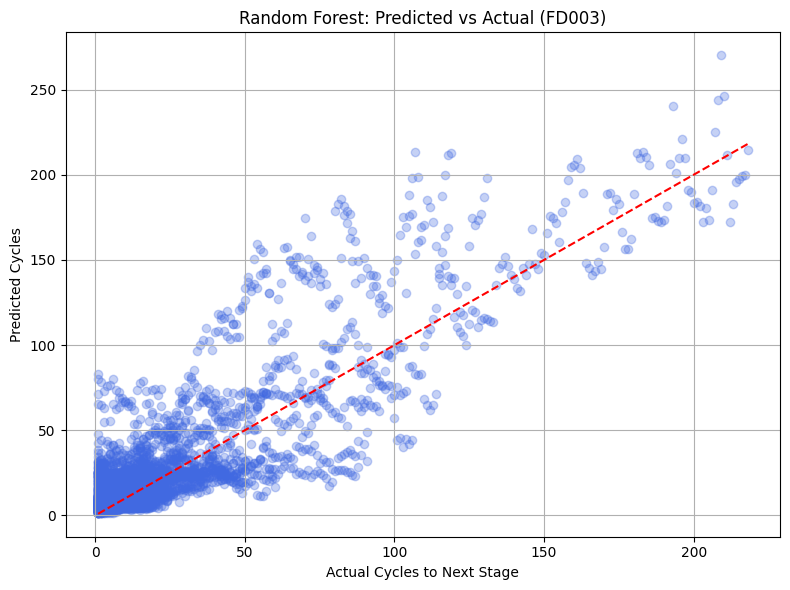

In [123]:
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_pred_vs_actual_fd003.png'))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Random Forest: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_path)
print(f"✅ Saved prediction plot to: {fig_path}")
plt.show()


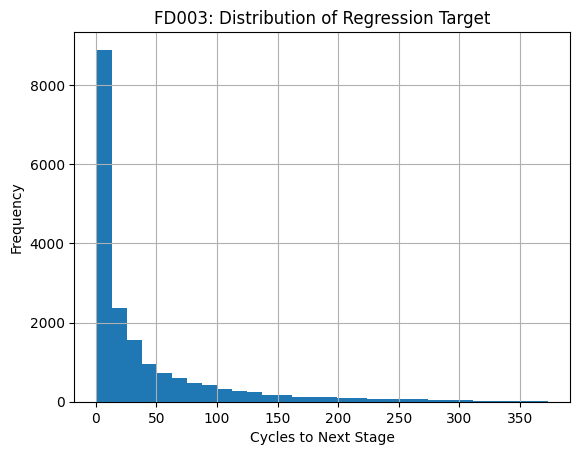

In [124]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Reload FD003 if needed
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
file_path = os.path.join(BASE_DIR, 'data', 'regression_train_FD003.csv')
df_fd003 = pd.read_csv(file_path)

# Plot
df_fd003['cycles_to_next_stage'].hist(bins=30)
plt.xlabel('Cycles to Next Stage')
plt.ylabel('Frequency')
plt.title('FD003: Distribution of Regression Target')
plt.grid(True)
plt.show()


### Step 3E – Save Trained Random Forest Model
We save the trained model using joblib for reuse in Step 9 ensemble or deployment.

In [125]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'rf_regressor_fd003.pkl'))
joblib.dump(rf_regressor, model_path)
print(f" Model saved to: {model_path}")


 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\rf_regressor_fd003.pkl


###  Step 3F – Plot: Feature Importances
This explains which features the model relied on most for its predictions

 Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_feature_importance_fd003.png


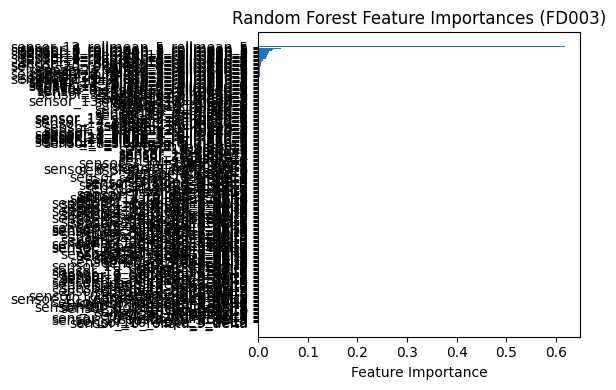

In [126]:
importances = rf_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(X_train.columns)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(X_train.columns)), [X_train.columns[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (FD003)")
plt.tight_layout()

# Save plot
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_feature_importance_fd003.png'))
plt.savefig(feat_imp_path)
print(f" Feature importance plot saved to: {feat_imp_path}")
plt.show()


In [127]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os


In [128]:
# Initialize XGBoost Regressor
xgb_regressor = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_regressor.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [129]:
# Predict on test set
y_pred_xgb = xgb_regressor.predict(X_test)

# Evaluation metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(" XGBoost Evaluation Metrics (FD003):")
print(f" RMSE: {rmse_xgb:.2f}")
print(f" MAE : {mae_xgb:.2f}")
print(f" R²  : {r2_xgb:.4f}")


 XGBoost Evaluation Metrics (FD003):
 RMSE: 21.26
 MAE : 13.05
 R²  : 0.6548


In [130]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(xgb_regressor, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
cv_mae  = -cross_val_score(xgb_regressor, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
cv_r2   = cross_val_score(xgb_regressor, X_train, y_train, cv=cv, scoring='r2')

print("\nCross-Validation Evaluation (XGBoost – FD003):")
print(f"CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"CV MAE : {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")
print(f"CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")



Cross-Validation Evaluation (XGBoost – FD003):
CV RMSE: 21.09 ± 0.83
CV MAE : 13.23 ± 0.33
CV R²  : 0.8889 ± 0.0115


✅ Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_pred_vs_actual_fd003.png


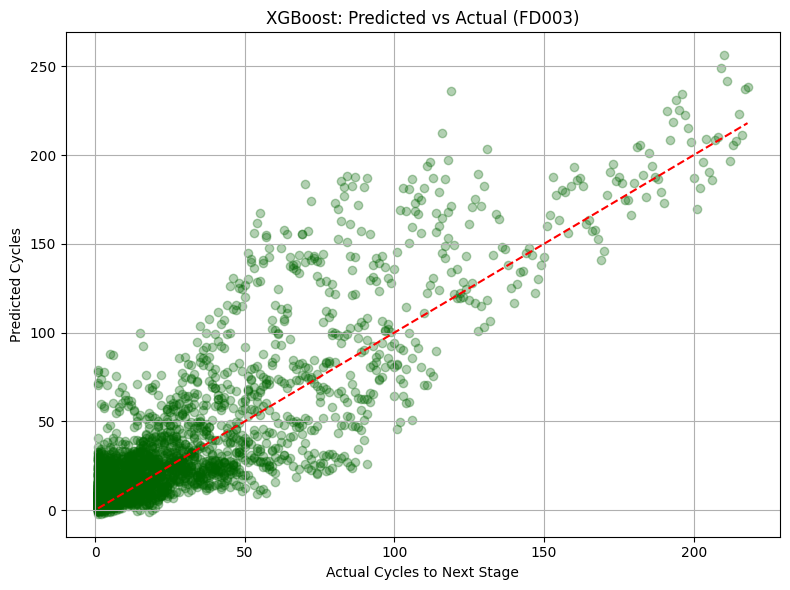

In [131]:
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_pred_vs_actual_fd003.png'))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("XGBoost: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_path)
print(f"✅ Saved prediction plot to: {fig_path}")
plt.show()


In [132]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [133]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

best_score = float('inf')
best_model = None
best_params = None

for n in param_grid['n_estimators']:
    for d in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:
            for ss in param_grid['subsample']:
                for cs in param_grid['colsample_bytree']:
                    model = xgb.XGBRegressor(
                        n_estimators=n,
                        max_depth=d,
                        learning_rate=lr,
                        subsample=ss,
                        colsample_bytree=cs,
                        random_state=42,
                        n_jobs=-1
                    )
                    model.fit(X_train, y_train)
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))  # ✅ fixed
r2 = r2_score(y_test, preds)


print(f"✅ Params: n={n}, depth={d}, lr={lr}, ss={ss}, cs={cs} → RMSE={rmse:.2f}, R²={r2:.4f}")
                    
if rmse < best_score:
                        best_score = rmse
                        best_model = model
                        best_params = {
                            'n_estimators': n,
                            'max_depth': d,
                            'learning_rate': lr,
                            'subsample': ss,
                            'colsample_bytree': cs
                        }

print("\n🎯 Best Params:")
print(best_params)
print(f"✅ Best RMSE: {best_score:.2f}")


✅ Params: n=300, depth=10, lr=0.1, ss=1.0, cs=1.0 → RMSE=23.04, R²=0.5947

🎯 Best Params:
{'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0}
✅ Best RMSE: 23.04


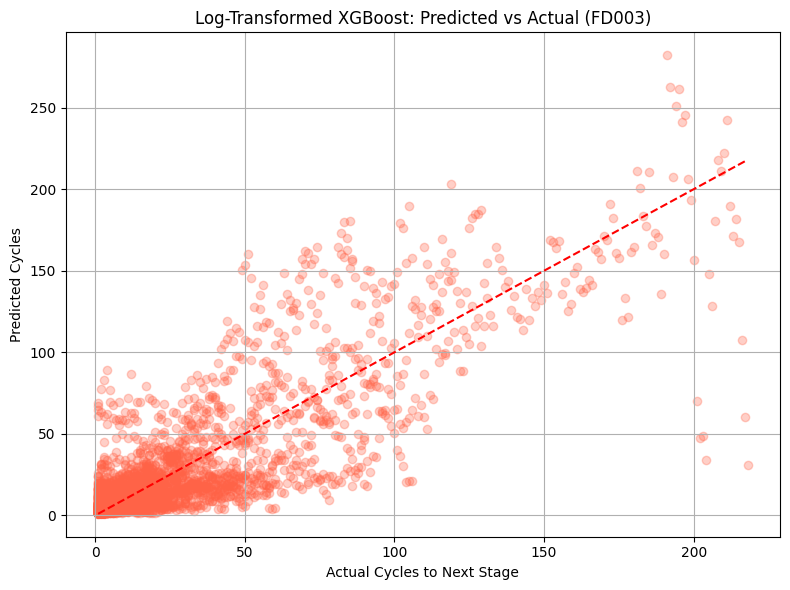

📊 Log-Transformed XGB → RMSE: 20.86 | R²: 0.6675


In [134]:
# ✅ Apply log transformation on the target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# ✅ Re-train XGBoost with best params on log-transformed target
xgb_log = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

xgb_log.fit(X_train, y_train_log)

# ✅ Predict and reverse log
y_pred_log = xgb_log.predict(X_test)
y_pred_final = np.expm1(y_pred_log)  # inverse of log1p

# ✅ Evaluate
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_log = r2_score(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.3, color='tomato')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Log-Transformed XGBoost: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"📊 Log-Transformed XGB → RMSE: {rmse_log:.2f} | R²: {r2_log:.4f}")


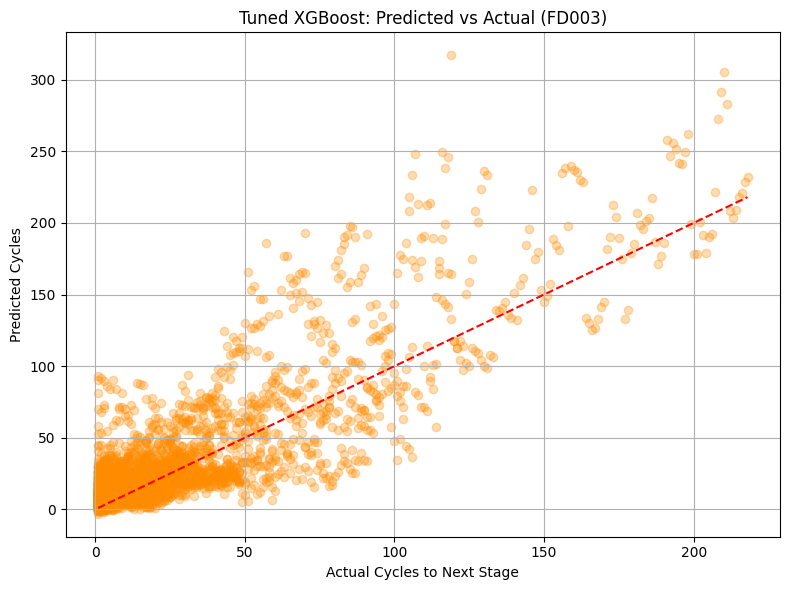

In [135]:
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Tuned XGBoost: Predicted vs Actual (FD003)")
plt.grid(True)
plt.tight_layout()
plt.show()
